# Đánh giá điểm hội tụ của các hàm Fitness và Heuristic Mutation

Notebook này thực hiện các thí nghiệm để so sánh tốc độ hội tụ của thuật toán di truyền (GA) với các cấu hình khác nhau:
1. **Fitness Functions**: `weighted`, `penalty`, `alpha_beta`, `lexicographic`.
2. **Mutation Strategies**: `random`, `swap`, `creep`, `heuristic`.

In [ ]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Any
import dataclasses

sys.path.append(os.path.dirname(os.getcwd()))

from app import data_store

data_store.init()

from app.schemas.schedule_request import (
    ScheduleRequest,
    GAConfig,
    FitnessConfig,
    MutationConfig,
)
from app.ga.scheduler import GAScheduler
from app.schemas.chromosome import Chromosome
from app.ga.elitism import get_elites
from app.ga.selection import pick_selection_method
from app.ga.crossover import crossover_population
from app.ga.mutation import mutate_population

## 1. Định nghĩa TrackedGAScheduler

Chúng ta kế thừa `GAScheduler` để ghi lại fitness tốt nhất qua từng thế hệ.

In [2]:
class TrackedGAScheduler(GAScheduler):
    def __init__(self, request_data: Any):
        super().__init__(request_data)
        self.history = []

    def run_tracked(self):
        self.initialize()
        from app.ga.stopping import StoppingCondition
        from app.ga.fitness import evaluate_all_constraints

        self.stopping = StoppingCondition(
            max_generations=self.ga_cfg.max_generations,
            target_fitness=self.ga_cfg.target_fitness,
            max_time_seconds=self.ga_cfg.max_time_seconds,
            max_stall_generations=self.ga_cfg.max_stall_generations,
            base_mutation_rate=self.mut_cfg.rate,
            max_mutation_rate=min(1.0, self.mut_cfg.rate * 5),
        )
        self.stopping.reset()

        self.evaluate(self.population)

        for generation in range(self.ga_cfg.max_generations):
            current_best = max(self.population, key=lambda ind: ind.fitness)
            current_best_fitness = current_best.fitness

            # Track hard violations, soft scores, and raw fitness
            hard_counts, _, soft_scores, _ = evaluate_all_constraints(
                current_best,
                self.courses_dict,
                self.lecturers_dict,
                self.rooms_dict,
                self.timeslots_dict,
            )
            hard_violations = sum(hard_counts.values())
            soft_score = sum(soft_scores.values())

            scalar_fitness = current_best_fitness
            if isinstance(current_best_fitness, tuple):
                # Scalarize lexicographical: 1000/(1+hard_viols) + soft_score
                # Note: current_best_fitness[0] is -hard_violations
                hard_viols = -current_best_fitness[0]
                scalar_fitness = 1000 / (1 + hard_viols) + current_best_fitness[1]

            # History stores (hard_violations, soft_score, raw_fitness)
            self.history.append((hard_violations, soft_score, float(scalar_fitness)))

            if self.best_chromosome is None or current_best_fitness > self.best_fitness:
                self.best_fitness = current_best_fitness
                self.best_chromosome = Chromosome(
                    genes=[dataclasses.replace(g) for g in current_best.genes],
                    fitness=current_best.fitness,
                )

            should_stop, _ = self.stopping.check_stop_and_adapt(
                generation, float(scalar_fitness)
            )
            if should_stop:
                break

            # GA Operators
            elites = get_elites(self.population, self.ga_cfg.elitism_rate)
            num_parents = self.ga_cfg.pop_size - len(elites)
            parents = pick_selection_method(
                self.population,
                num_parents,
                self.sel_cfg.method,
                self.sel_cfg.tournament_k,
            )
            offspring = crossover_population(
                parents,
                self.cross_cfg.method,
                self.cross_cfg.rate,
                self.cross_cfg.n_points,
            )
            offspring = mutate_population(
                offspring,
                list(self.lecturers_dict.values()),
                list(self.rooms_dict.values()),
                list(self.timeslots_dict.values()),
                method=self.mut_cfg.method,
                mutation_rate=self.stopping.current_mutation_rate,
                courses_dict=self.courses_dict,
                lecturers_dict=self.lecturers_dict,
                rooms_dict=self.rooms_dict,
                timeslots_dict=self.timeslots_dict,
            )
            self.evaluate(offspring)
            self.population = elites + offspring

        return self.history

In [3]:
def plot_comparison_results(results_dict: Dict[str, List], title_suffix: str):
    """
    Vẽ bảng so sánh 2x2:
    - Top-Left: Convergence Hard Violations
    - Top-Right: Final Hard Violations (Bar)
    - Bottom-Left: Convergence Soft Scores
    - Bottom-Right: Final Soft Scores (Bar)
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    colors = plt.cm.viridis(np.linspace(0, 1, len(results_dict)))

    methods = list(results_dict.keys())
    final_h = [results_dict[m][-1][0] for m in methods]
    final_s = [results_dict[m][-1][1] for m in methods]

    # 1. Hard Violations Convergence
    for i, (method, history) in enumerate(results_dict.items()):
        h_viols = [h[0] for h in history]
        axes[0, 0].plot(h_viols, label=method, color=colors[i], alpha=0.8)
    axes[0, 0].set_title(f"Hội tụ Hard Constraints - {title_suffix}")
    axes[0, 0].set_ylabel("Số lỗi Hard")
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle="--", alpha=0.6)

    # 2. Final Hard Violations Comparison (Bar)
    bars0 = axes[0, 1].bar(methods, final_h, color=colors, alpha=0.7)
    axes[0, 1].set_title(f"So sánh lỗi Hard cuối cùng - {title_suffix}")
    axes[0, 1].set_ylabel("Số lỗi Hard")
    for bar in bars0:
        yval = bar.get_height()
        axes[0, 1].text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.1,
            int(yval),
            ha="center",
            va="bottom",
        )

    # 3. Soft Score Convergence
    for i, (method, history) in enumerate(results_dict.items()):
        s_scores = [h[1] for h in history]
        axes[1, 0].plot(s_scores, label=method, color=colors[i], alpha=0.8)
    axes[1, 0].set_title(f"Hội tụ Soft Score - {title_suffix}")
    axes[1, 0].set_ylabel("Điểm Soft")
    axes[1, 0].set_xlabel("Thế hệ")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle="--", alpha=0.6)

    # 4. Final Soft Score Comparison (Bar)
    bars1 = axes[1, 1].bar(methods, final_s, color=colors, alpha=0.7)
    axes[1, 1].set_title(f"So sánh điểm Soft cuối cùng - {title_suffix}")
    axes[1, 1].set_ylabel("Điểm Soft")
    axes[1, 1].set_xlabel("Phương pháp")
    for bar in bars1:
        yval = bar.get_height()
        axes[1, 1].text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.1,
            int(yval),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


def plot_fitness_vs_generations(results_dict: Dict[str, List], title: str):
    """
    Vẽ biểu đồ với X = Fitness Score và Y = Generations
    """
    plt.figure(figsize=(12, 8))
    colors = plt.cm.plasma(np.linspace(0, 1, len(results_dict)))

    for i, (method, history) in enumerate(results_dict.items()):
        fitness_scores = [h[2] for h in history]
        generations = list(range(len(history)))
        plt.plot(
            generations, fitness_scores, label=method, color=colors[i], linewidth=2
        )

    plt.title(title, fontsize=14)
    plt.xlabel("Thế hệ (Generations)", fontsize=12)
    plt.ylabel("Fitness Score (Scalar)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.show()

## 2. Thí nghiệm so sánh Fitness Functions

Cố định đột biến là `heuristic`.

In [4]:
fitness_methods = ["weighted", "penalty", "alpha_beta", "lexicographic"]
fitness_results = {}

common_ga_cfg = GAConfig(pop_size=50, max_generations=100)
common_mut_cfg = MutationConfig(method="heuristic", rate=0.1)

print("Bắt đầu thí nghiệm Fitness Functions...")
for method in fitness_methods:
    print(f"  - Đang chạy với {method}...")
    req = ScheduleRequest(
        fitness=FitnessConfig(method=method), mutation=common_mut_cfg, ga=common_ga_cfg
    )
    scheduler = TrackedGAScheduler(req)
    history = scheduler.run_tracked()
    fitness_results[method] = history

print("Hoàn tất.")

Bắt đầu thí nghiệm Fitness Functions...
  - Đang chạy với weighted...
=== SESSIONS ===
course: CT052-M01 | session: 1 | units: 3
course: CT052-M01 | session: 2 | units: 3
course: CT052-M01 | session: 3 | units: 3
course: CT052-M02 | session: 1 | units: 3
course: CT052-M02 | session: 2 | units: 3
course: CT052-M02 | session: 3 | units: 3
course: CT101-M01 | session: 1 | units: 3
course: CT101-M01 | session: 2 | units: 3
course: CT101-M01 | session: 3 | units: 3
course: CT101-M01 | session: 4 | units: 3
course: CT101-M02 | session: 1 | units: 3
course: CT101-M02 | session: 2 | units: 3
course: CT101-M02 | session: 3 | units: 3
course: CT101-M02 | session: 4 | units: 3
course: CT101-M03 | session: 1 | units: 3
course: CT101-M03 | session: 2 | units: 3
course: CT101-M03 | session: 3 | units: 3
course: CT101-M03 | session: 4 | units: 3
course: CT053-M01 | session: 1 | units: 3
course: CT053-M01 | session: 2 | units: 3
course: CT053-M01 | session: 3 | units: 3
course: CT201-M01 | session: 1 

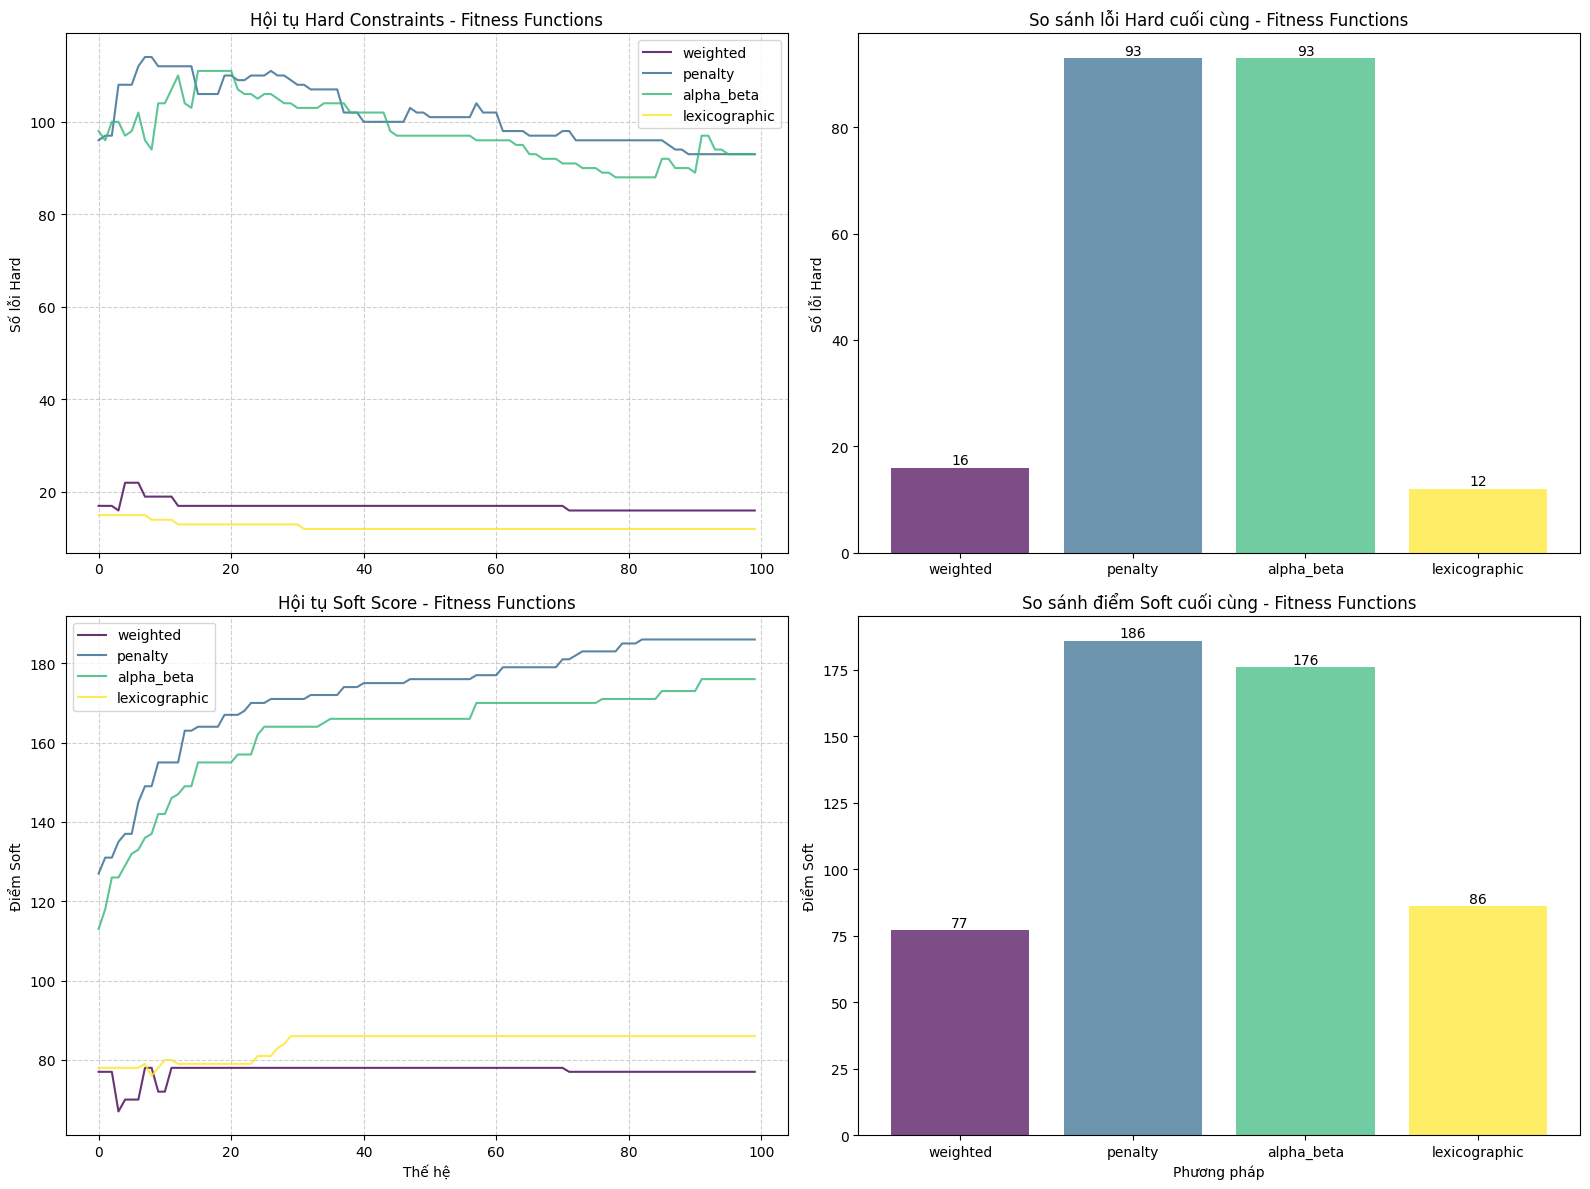

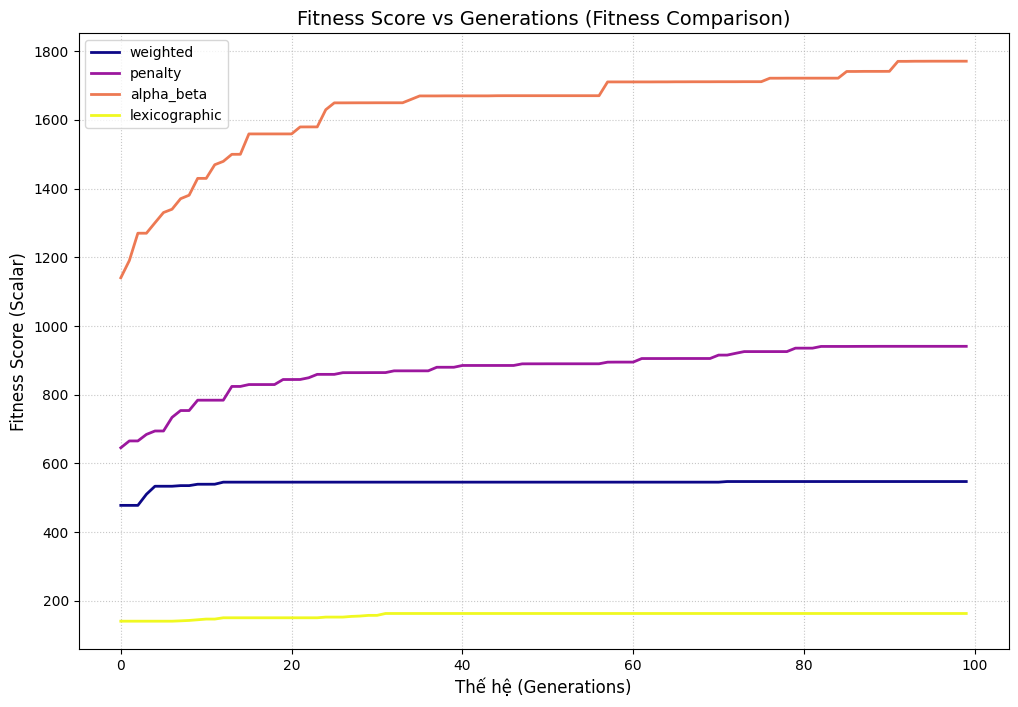

In [5]:
plot_comparison_results(fitness_results, "Fitness Functions")
plot_fitness_vs_generations(
    fitness_results, "Fitness Score vs Generations (Fitness Comparison)"
)

## 3. Thí nghiệm so sánh Mutation Strategies

Cố định fitness là `weighted`.

In [6]:
mutation_methods = ["random", "swap", "creep", "heuristic"]
mutation_results = {}

common_fit_cfg = FitnessConfig(method="weighted")
common_ga_cfg = GAConfig(pop_size=50, max_generations=100)

print("Bắt đầu thí nghiệm Mutation Strategies...")
for method in mutation_methods:
    print(f"  - Đang chạy với {method}...")
    req = ScheduleRequest(
        fitness=common_fit_cfg,
        mutation=MutationConfig(method=method, rate=0.1),
        ga=common_ga_cfg,
    )
    scheduler = TrackedGAScheduler(req)
    history = scheduler.run_tracked()
    mutation_results[method] = history

print("Hoàn tất.")

Bắt đầu thí nghiệm Mutation Strategies...
  - Đang chạy với random...
=== SESSIONS ===
course: CT052-M01 | session: 1 | units: 3
course: CT052-M01 | session: 2 | units: 3
course: CT052-M01 | session: 3 | units: 3
course: CT052-M02 | session: 1 | units: 3
course: CT052-M02 | session: 2 | units: 3
course: CT052-M02 | session: 3 | units: 3
course: CT101-M01 | session: 1 | units: 3
course: CT101-M01 | session: 2 | units: 3
course: CT101-M01 | session: 3 | units: 3
course: CT101-M01 | session: 4 | units: 3
course: CT101-M02 | session: 1 | units: 3
course: CT101-M02 | session: 2 | units: 3
course: CT101-M02 | session: 3 | units: 3
course: CT101-M02 | session: 4 | units: 3
course: CT101-M03 | session: 1 | units: 3
course: CT101-M03 | session: 2 | units: 3
course: CT101-M03 | session: 3 | units: 3
course: CT101-M03 | session: 4 | units: 3
course: CT053-M01 | session: 1 | units: 3
course: CT053-M01 | session: 2 | units: 3
course: CT053-M01 | session: 3 | units: 3
course: CT201-M01 | session: 1 

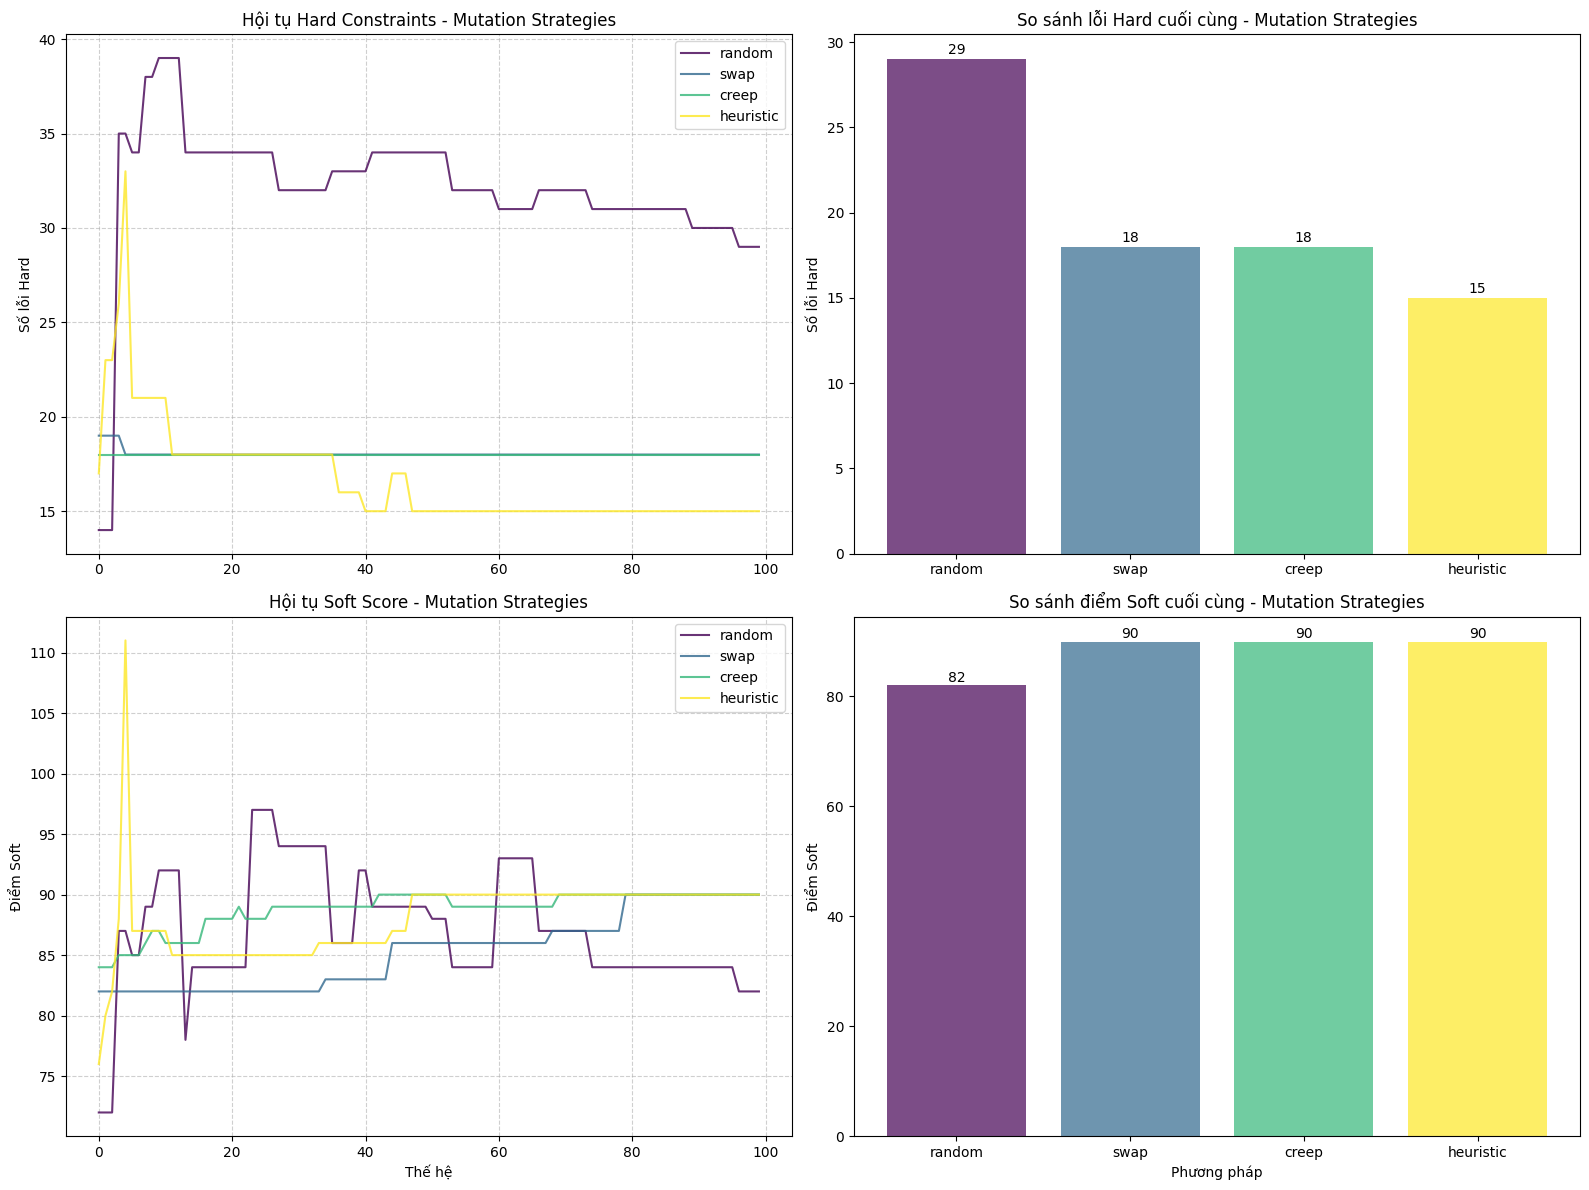

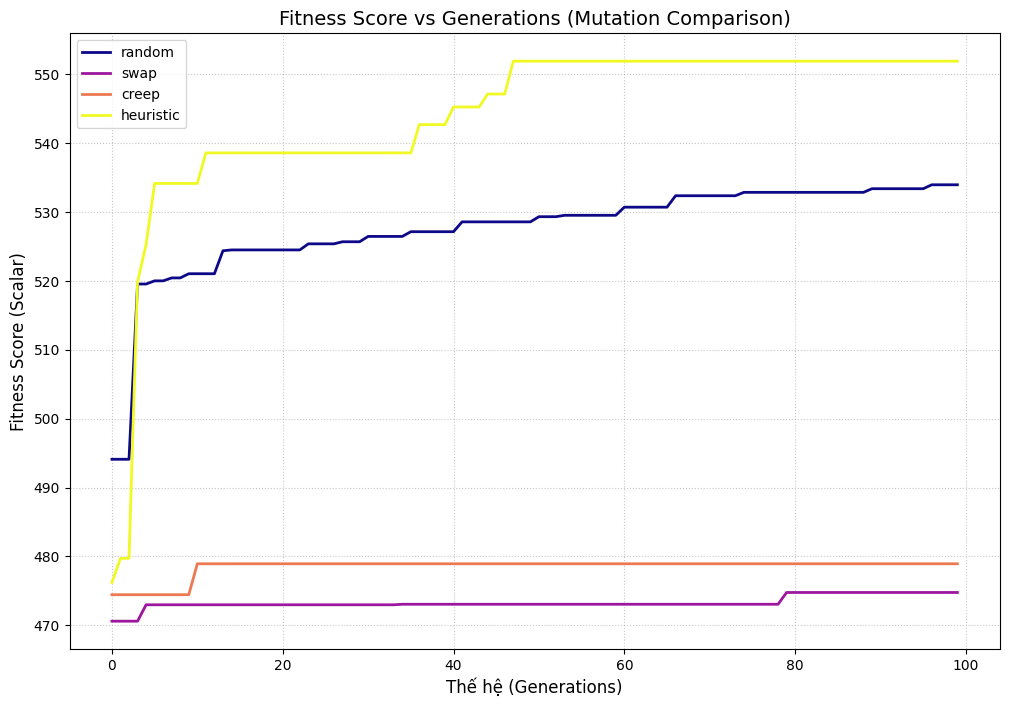

In [7]:
plot_comparison_results(mutation_results, "Mutation Strategies")
plot_fitness_vs_generations(
    mutation_results, "Fitness Score vs Generations (Mutation Comparison)"
)

In [8]:
print(
    "{:<20} | {:<10} | {:<10} | {:<20}".format(
        "Method", "Hard Viols", "Soft Score", "Generations"
    )
)
print("-" * 80)

print("Fitness Functions Comparison:")
for method, history in fitness_results.items():
    h_final, s_final, f_final = history[-1]
    print(
        "{:<20} | {:<10.0f} | {:<10.0f} | {:<20}".format(
            method, h_final, s_final, len(history)
        )
    )

print("\nMutation Strategies Comparison:")
for method, history in mutation_results.items():
    h_final, s_final, f_final = history[-1]
    print(
        "{:<20} | {:<10.0f} | {:<10.0f} | {:<20}".format(
            method, h_final, s_final, len(history)
        )
    )

Method               | Hard Viols | Soft Score | Generations         
--------------------------------------------------------------------------------
Fitness Functions Comparison:
weighted             | 16         | 77         | 100                 
penalty              | 93         | 186        | 100                 
alpha_beta           | 93         | 176        | 100                 
lexicographic        | 12         | 86         | 100                 

Mutation Strategies Comparison:
random               | 29         | 82         | 100                 
swap                 | 18         | 90         | 100                 
creep                | 18         | 90         | 100                 
heuristic            | 15         | 90         | 100                 
